# College Production Vs. Draft Position Analysis 

Now that we have the production based on draft position, I want to find why receivers get drafted where they do. The first step I want to take is seeing how college yards/game translates into average draft positon! Keep in mind, these stats are from the 300 top college football receiving yards season by year. So players who have seasons outside of the top 300 in terms of receiving yards will now show up.

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
    SELECT c.Player,
           SUM(c.G) AS games_played,
           d.Player AS overall_pick, 
           c.Year,
           AVG(c.RecYperG) AS YDSperGame
    FROM college c
    LEFT JOIN draft_picks d 
    ON   d.Name = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
    GROUP BY c.Player
    ORDER BY 3 
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("WR COLLEGE YPG BY DRAFT PICK (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

conn.close()

WR COLLEGE YPG BY DRAFT PICK (2017-2025)
                  Player  games_played  overall_pick  YEAR  YDSperGame
           Travis Hunter            22             2  2023   88.450000
           Ja'Marr Chase            14             5  2019  127.100000
           Jaylen Waddle            34             6  2018   66.033333
            Malik Nabers            38             6  2021   77.066667
            Drake London            27             8  2019   87.600000
       Tetairoa McMillan            37             8  2022   92.066667
             Rome Odunze            36             9  2021   83.600000
           DeVonta Smith            40            10  2018   96.300000
          Garrett Wilson            33            10  2019   72.500000
             Chris Olave            33            11  2019   80.900000
        Jameson Williams            15            12  2021  104.800000
             Jerry Jeudy            28            15  2018   88.600000
            Jahan Dotson            

***
Now that we have this information, I want to know how many players with x ypg get drafted in each position as mentioned below:

##### Draft Capital Buckets
| Bucket | Pick Range | 
| :--- | :--- |
| Premium | 1-10 |
| Round 1 | 11-32 |
| Round 2 | 33-64 |
| Round 3 | 65-96 |
| Round 4 | 97-128 |
| Round 5-7 | 129+ |


##### Yards Per Game Buckets
| Bucket | YPG Range | 
| :--- | :--- |
| Elite | 90+ YPG |
| Great | 70-90 YPG |
| Good | 50-70 YPG |
| Role | 30-50 |
| Below Average | 0-30 YPG |

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_avg_ypg AS (
    SELECT 
        c.Player,
        d.Player as Pick,
        d.Round,
        AVG(c.RecYperG) AS avg_ypg
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
    GROUP BY c.Player
),
player_with_buckets AS(
    SELECT Player,
           Pick,
           Round,
           avg_ypg,
           CASE
                WHEN Pick <= 10 THEN '1-10 (Premium)'
                WHEN Pick <= 32 THEN '11-32 (Round 1)'
                WHEN Pick <= 64 THEN '33-64 (Round 2)'
                WHEN Pick <= 96 THEN '65-96 (Round 3)'
                WHEN Pick <= 128 THEN '97-128 (Round 4)'
                ELSE '129+ (Round 5-7)'
           END AS pick_range,
           CASE 
                WHEN avg_ypg < 30 THEN '0-30 YPG'
                WHEN avg_ypg < 50 THEN '30-50 YPG'
                WHEN avg_ypg < 70 THEN '50-70 YPG'
                WHEN avg_ypg < 90 THEN '70-90 YPG'
                ELSE '90+ YPG'
           END as ypg_range
    FROM player_avg_ypg
)
SELECT pick_range, 
       ypg_range, 
       COUNT(*) as player_count
FROM player_with_buckets
GROUP BY pick_range, ypg_range
ORDER BY pick_range, ypg_range
"""



# execute and display
results = pd.read_sql_query(query, conn)

print("WR COLLEGE YPG BY DRAFT PICK (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

conn.close()

WR COLLEGE YPG BY DRAFT PICK (2017-2025)
      pick_range ypg_range  player_count
  1-10 (Premium) 50-70 YPG             1
  1-10 (Premium) 70-90 YPG             5
  1-10 (Premium)   90+ YPG             3
 11-32 (Round 1) 50-70 YPG             7
 11-32 (Round 1) 70-90 YPG            14
 11-32 (Round 1)   90+ YPG             3
129+ (Round 5-7) 30-50 YPG            21
129+ (Round 5-7) 50-70 YPG            40
129+ (Round 5-7) 70-90 YPG            31
129+ (Round 5-7)   90+ YPG             9
 33-64 (Round 2) 30-50 YPG             4
 33-64 (Round 2) 50-70 YPG            14
 33-64 (Round 2) 70-90 YPG            13
 33-64 (Round 2)   90+ YPG             6
 65-96 (Round 3) 30-50 YPG             6
 65-96 (Round 3) 50-70 YPG            11
 65-96 (Round 3) 70-90 YPG             8
 65-96 (Round 3)   90+ YPG             4
97-128 (Round 4) 30-50 YPG             3
97-128 (Round 4) 50-70 YPG             8
97-128 (Round 4) 70-90 YPG             9
97-128 (Round 4)   90+ YPG             2


***
### Visualization
This is a lot of numbers that I don't know how to make sense of. Let's make a bar chart!

CREATING VISUALIZATION...


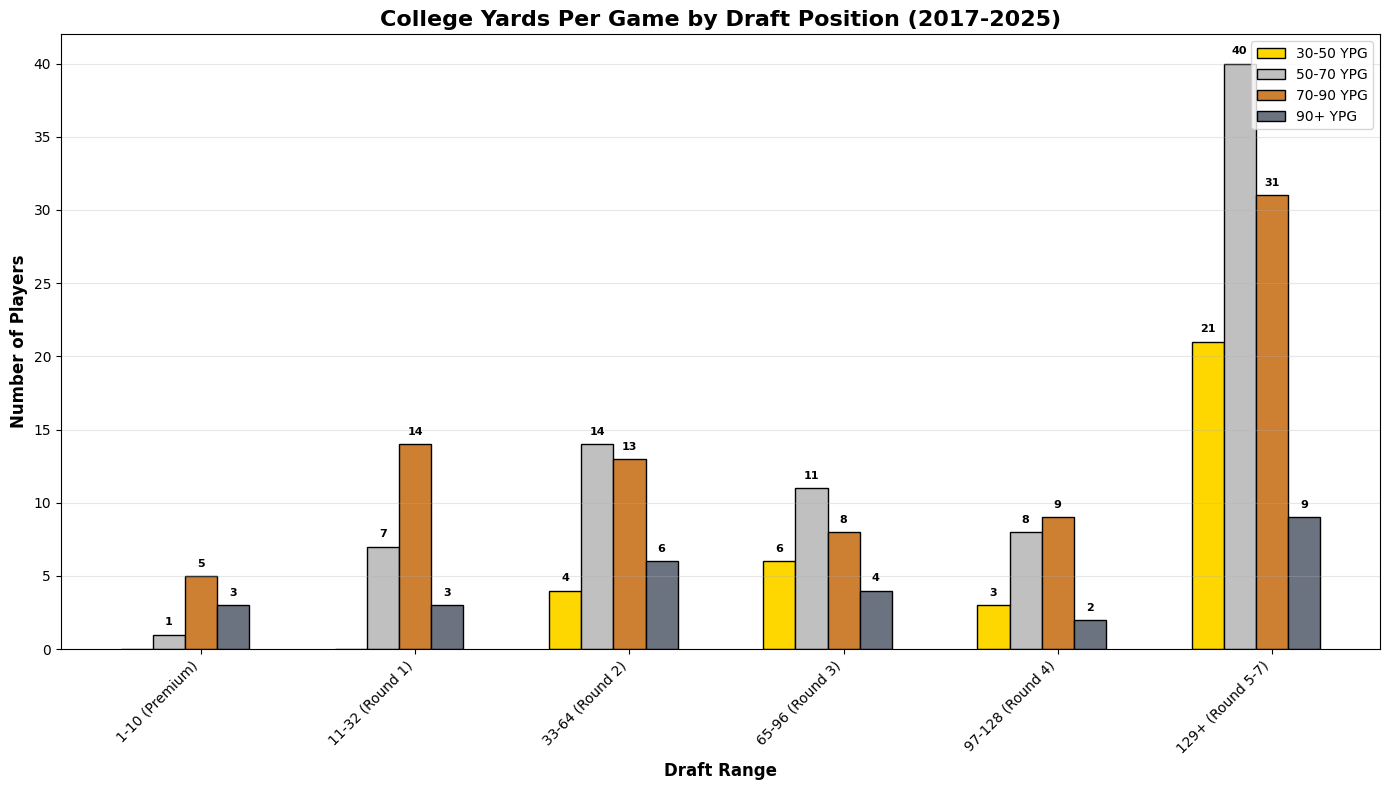


📋 RAW NUMBERS BY DRAFT RANGE:
ypg_range         30-50 YPG  50-70 YPG  70-90 YPG  90+ YPG
pick_range                                                
1-10 (Premium)          0.0        1.0        5.0      3.0
11-32 (Round 1)         0.0        7.0       14.0      3.0
33-64 (Round 2)         4.0       14.0       13.0      6.0
65-96 (Round 3)         6.0       11.0        8.0      4.0
97-128 (Round 4)        3.0        8.0        9.0      2.0
129+ (Round 5-7)       21.0       40.0       31.0      9.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np

print("CREATING VISUALIZATION...")
print("=" * 60)

# first, let's pivot the data to get it in the right format
pivot_data = results.pivot(index='pick_range', columns='ypg_range', values='player_count').fillna(0)

# define the order for pick ranges
pick_order = ['1-10 (Premium)', '11-32 (Round 1)', '33-64 (Round 2)', 
              '65-96 (Round 3)', '97-128 (Round 4)', '129+ (Round 5-7)']
ypg_order = ['30-50 YPG', '50-70 YPG', '70-90 YPG', '90+ YPG']

# reindex to ensure correct order
pivot_data = pivot_data.reindex(index=pick_order, columns=ypg_order)

# set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# set up bar positions
x = np.arange(len(pick_order))
width = 0.15  # Slightly smaller to fit 5 bars

# colors for each YPG range
colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280', '#2E4057']

# create bars for each YPG range
bars = []
for i, ypg in enumerate(ypg_order):
    bar = ax.bar(x + (i - 2) * width, pivot_data[ypg].values, width, 
                 label=ypg, color=colors[i], edgecolor='black')
    bars.append(bar)

# customize the chart
ax.set_xlabel('Draft Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=12, fontweight='bold')
ax.set_title('College Yards Per Game by Draft Position (2017-2025)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pick_order, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# add value labels on bars
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('college_ypg_by_draft_range.png', dpi=300, bbox_inches='tight')
plt.show()

# Show the raw data
print("\n📋 RAW NUMBERS BY DRAFT RANGE:")
print("=" * 60)
print(pivot_data.to_string())

### FINDINGS
This data shows us almost nothing, which in it of itself shows us something! There is not strong correlation to YPG and pick range, meaning that this stat isn't a strong predictor of where a receiver is going to be picked in the draft. Therefore, if there is a player who a team has their eyes set on who didn't have great production in yardage, you can't bank on them being avaialble in later rounds. 
<br><br>

We have to find what is a good indicator of draft position! So for this, I first need to make a query to find multiple statistics from college receivers:

YPG <br>
YPC <br>
MAX REC TD <br>
40 Time <br>
Overall Pick 

In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_data AS (
    SELECT 
        c.Player,
        c.Conf,
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_td,
        com.`40yd` as forty_time,
        d.Player AS Pick,
        d.Year as draft_year,
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'SEC, BIG 10'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'ACC, BIG 12, PAC 12'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    LEFT JOIN combine com ON com.Player = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
        AND com.`40yd` IS NOT NULL  -- Only players with 40 time
        AND com.`40yd` > 0
    GROUP BY c.Player
)
SELECT * FROM player_data
ORDER BY Pick;
"""



# Execute and display
player_data = pd.read_sql_query(query, conn)

print("WR COLLEGE STATS AND PICKS (2017-2025)")
print("=" * 100)
print(player_data.to_string(index=False))


conn.close()

WR COLLEGE STATS AND PICKS (2017-2025)
                  Player     Conf  college_ypg  yards_per_catch  peak_td  forty_time  Pick  draft_year     conference_tier
           Ja'Marr Chase      SEC   127.100000        21.200000       20        4.34     5        2021         SEC, BIG 10
             Rome Odunze   Pac-12    83.600000        14.400000       13        4.45     9        2024 ACC, BIG 12, PAC 12
          Garrett Wilson  Big Ten    72.500000        15.433333       12        4.38    10        2022         SEC, BIG 10
             Chris Olave  Big Ten    80.900000        15.433333       13        4.39    11        2022         SEC, BIG 10
             Jerry Jeudy      SEC    88.600000        17.200000       14        4.45    15        2020         SEC, BIG 10
            Jahan Dotson  Big Ten    78.066667        16.033333       12        4.43    16        2022         SEC, BIG 10
             CeeDee Lamb   Big 12    80.800000        18.900000       14        4.50    17        20

I'll use this query in the next notebook on a scatterplot to see if there is anything I can find!

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)
#### [Combine Athleticism Scatter Plot](https://quinng8.github.io/nfl-draft-analytics/03_combine_scatter.html)